,path,locality,city,context,ptype,rep
0,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,bwt,i,2
1,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,vwk,i,3
2,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,vwp,i,3
3,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,pwv,a,3
4,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,pwf,i,3


🖼️ Salvato: 0707_bwk_r1.png


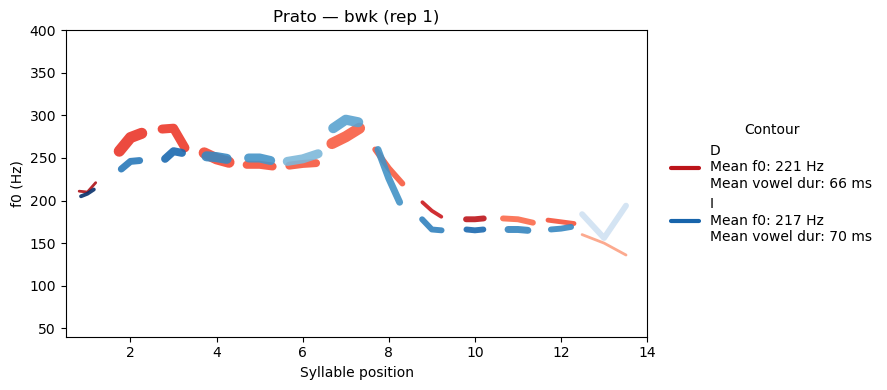

🖼️ Plot salvato: /Users/Federico/Desktop/Italia/plots_amper/0707_bwk_r1.png
🖼️ Salvato: 0707_bwk_r2.png


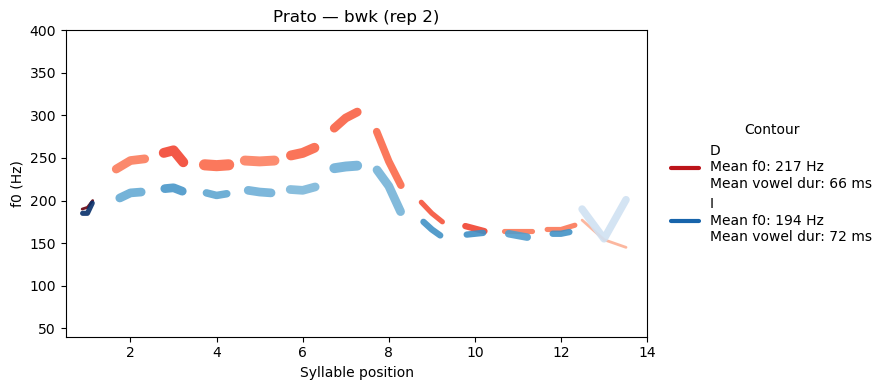

🖼️ Plot salvato: /Users/Federico/Desktop/Italia/plots_amper/0707_bwk_r2.png
🖼️ Salvato: 0707_bwk_r3.png


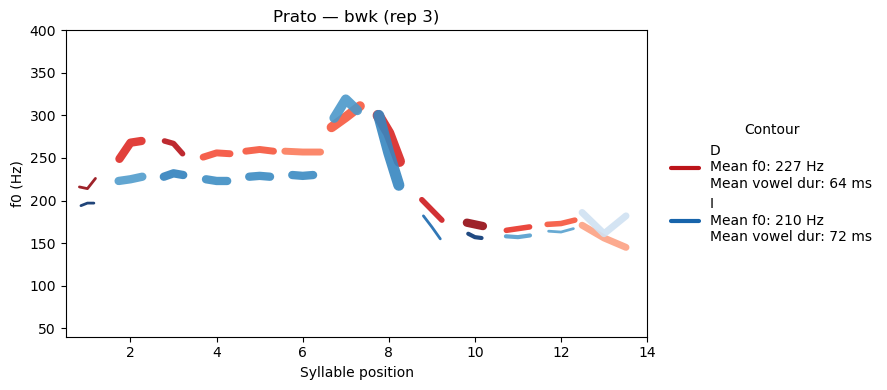

🖼️ Plot salvato: /Users/Federico/Desktop/Italia/plots_amper/0707_bwk_r3.png
🖼️ Salvato: 0724_bwk_r1.png


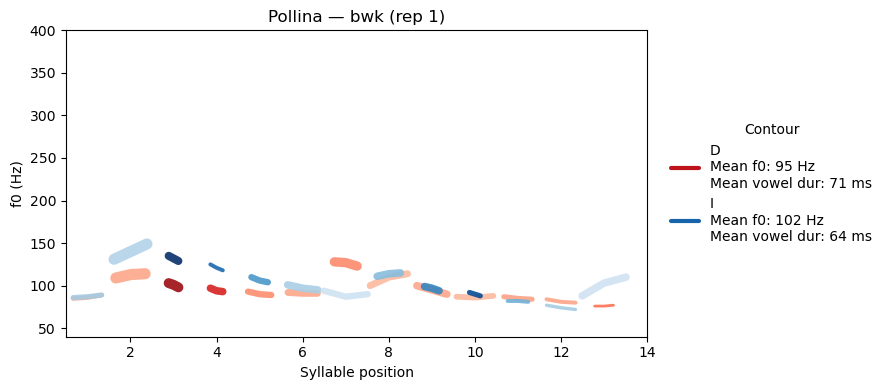

🖼️ Plot salvato: /Users/Federico/Desktop/Italia/plots_amper/0724_bwk_r1.png
🖼️ Salvato: 0724_bwk_r2.png


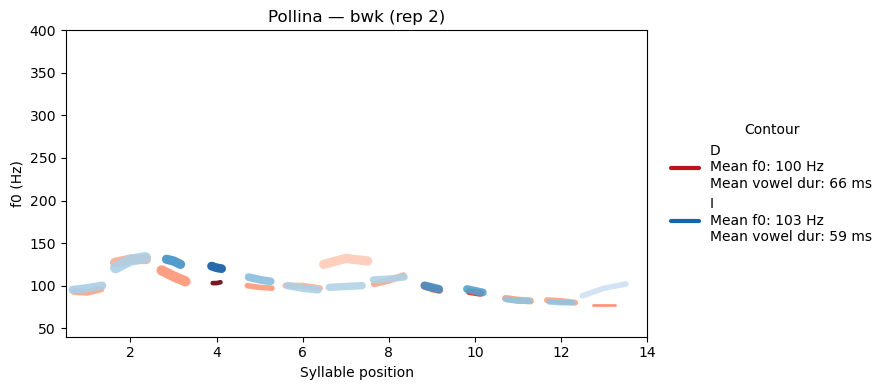

🖼️ Plot salvato: /Users/Federico/Desktop/Italia/plots_amper/0724_bwk_r2.png
🖼️ Salvato: 0724_bwk_r3.png


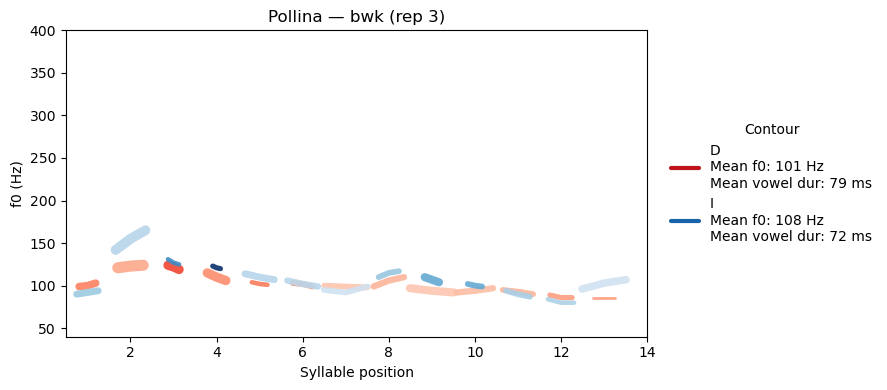

🖼️ Plot salvato: /Users/Federico/Desktop/Italia/plots_amper/0724_bwk_r3.png
🖼️ Salvato: 07e7_bwk_r1.png


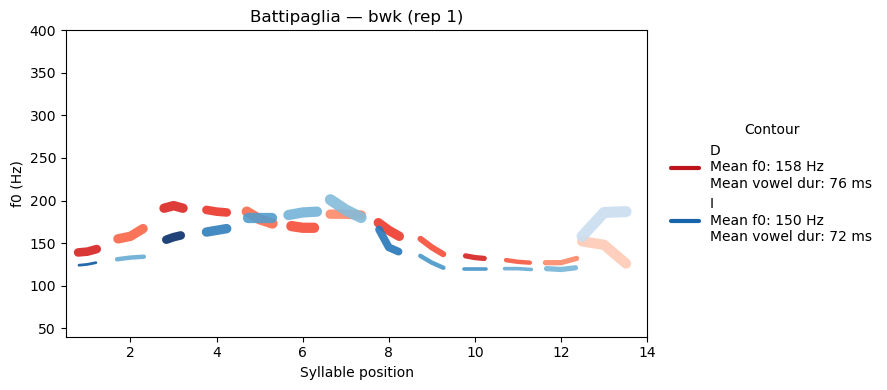

🖼️ Plot salvato: /Users/Federico/Desktop/Italia/plots_amper/07e7_bwk_r1.png
🖼️ Salvato: 07e7_bwk_r2.png


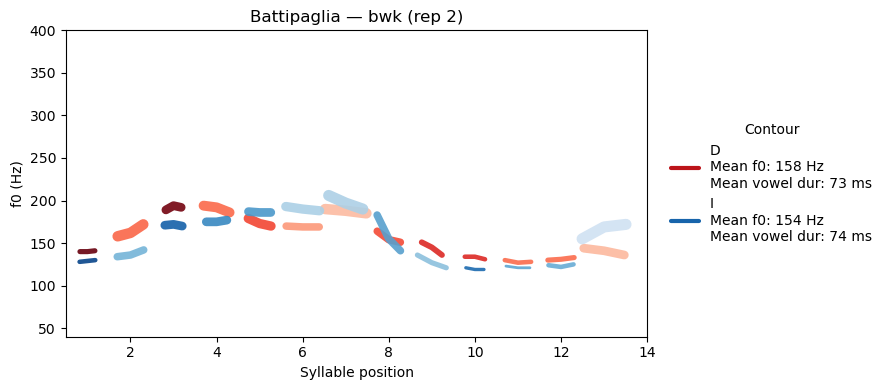

🖼️ Plot salvato: /Users/Federico/Desktop/Italia/plots_amper/07e7_bwk_r2.png
🖼️ Salvato: 07e7_bwk_r3.png


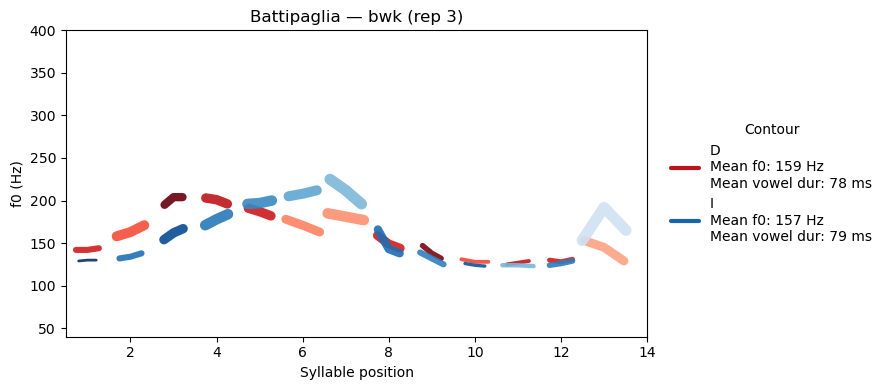

🖼️ Plot salvato: /Users/Federico/Desktop/Italia/plots_amper/07e7_bwk_r3.png
🖼️ Salvato: 07f3_bwk_r1.png


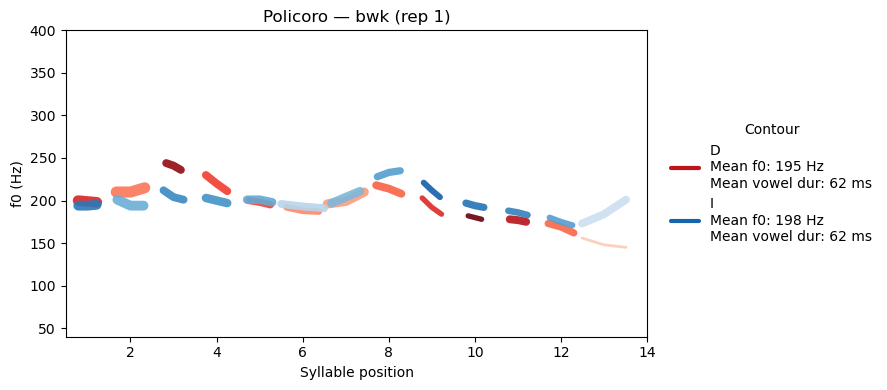

🖼️ Plot salvato: /Users/Federico/Desktop/Italia/plots_amper/07f3_bwk_r1.png
🖼️ Salvato: 07f3_bwk_r2.png


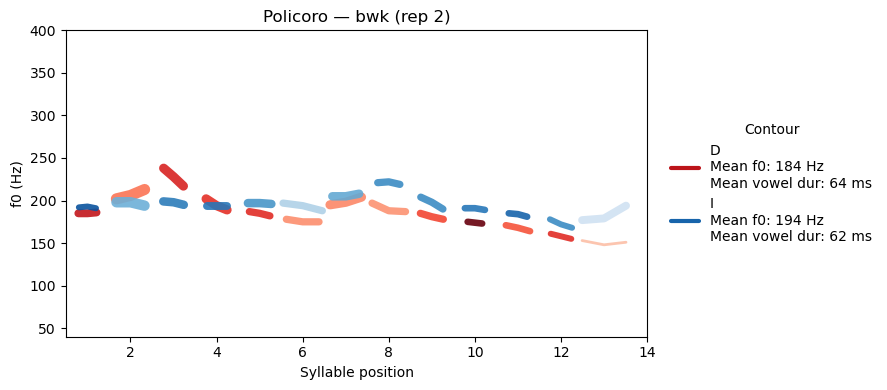

🖼️ Plot salvato: /Users/Federico/Desktop/Italia/plots_amper/07f3_bwk_r2.png
🖼️ Salvato: 07f3_bwk_r3.png


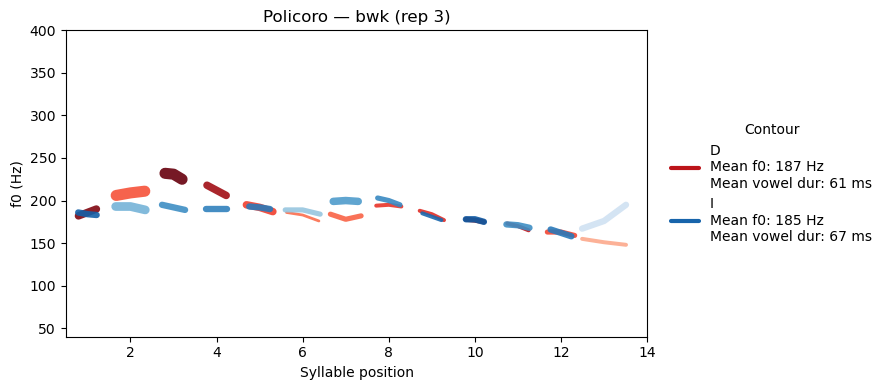

🖼️ Plot salvato: /Users/Federico/Desktop/Italia/plots_amper/07f3_bwk_r3.png


In [27]:
# ============================================================
# AMPER Intonation Visualizer + Batch Analysis
# ------------------------------------------------------------
# - Parsing file AMPER (.txt)
# - Visualizzazione segment-based (solo vocali, colori A vs I)
# - Scan ricorsivo cartelle wav_tgrid_txt_*
# - Plot esempi D (a) vs I (i)
# - Analisi statistica A vs I:
#     * Durata media nella PRIMA METÀ ESATTA dell’enunciato
#       (in termini di tempo, non solo "parte iniziale")
#     * F0 d’attacco: F0 medio nelle prime 3 sillabe
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from scipy import stats


# ============================================================
# 1) PARSING AMPER E COSTRUZIONE CURVE
# ============================================================

def parse_amper_txt(path):
    """
    Parser robusto per file AMPER.

    Struttura attesa (schematica):
        (header con percorso / data)
        duration [ms]   energy [dB]   fo1 fo2 fo3 [Hz]
        1   70   71   186 186 188
        ...
        values at:
        2616 4169 5721 ...

    Ritorna un dict con:
      - 'syll'      : indici sillabici (1..N)
      - 'dur_ms'    : durata sillabica (ms)
      - 'energy'    : energia sillabica (dB)
      - 'f0_points' : array Nx3 con i tre F0 per sillaba
      - 'times_raw' : array (3*N,) con i time-stamp AMPER
    """
    syll_idx = []
    dur_ms = []
    energy = []
    f0_points = []
    times_raw = []

    mode = "start"
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s:
                continue

            if "duration [ms]" in s and "fo3" in s:
                mode = "rows"
                continue

            if s.lower().startswith("values at"):
                mode = "times"
                continue

            if mode == "rows":
                parts = s.split()
                if not parts or not parts[0].isdigit():
                    continue
                if len(parts) < 5:
                    continue

                idx = int(parts[0])
                dur = float(parts[1])
                en  = parts[2]
                # gestiamo eventuali '--undefined--' nell'energia
                try:
                    en_val = float(en)
                except ValueError:
                    en_val = np.nan

                f0_vals = []
                for x in parts[-3:]:
                    try:
                        f0_vals.append(float(x))
                    except ValueError:
                        f0_vals.append(np.nan)

                syll_idx.append(idx)
                dur_ms.append(dur)
                energy.append(en_val)
                f0_points.append(f0_vals)

            elif mode == "times":
                for tok in s.split():
                    if tok.isdigit():
                        times_raw.append(int(tok))

    syll      = np.array(syll_idx if syll_idx else list(range(1, len(dur_ms) + 1)), dtype=int)
    dur_ms    = np.array(dur_ms, dtype=float)
    energy    = np.array(energy, dtype=float)
    f0_points = np.asarray(f0_points, dtype=float)
    times_raw = np.array(times_raw, dtype=float)

    return {
        "syll": syll,
        "dur_ms": dur_ms,
        "energy": energy,
        "f0_points": f0_points,
        "times_raw": times_raw,
    }


def _amper_timebase(dur_ms, times_raw):
    """
    Costruisce un asse temporale (in secondi) a partire da:
      - dur_ms    : durate sillabiche (ms)
      - times_raw : time-stamp AMPER (unità arbitrarie)

    Strategia:
      1. Normalizza times_raw su [0, 1] (preserva distanze relative).
      2. Riscalibra su [0, SUM(dur_ms)/1000] così che la durata
         complessiva coincida con la somma delle durate sillabiche.
    """
    dur_ms    = np.asarray(dur_ms, float)
    times_raw = np.asarray(times_raw, float)

    total_sec = float(dur_ms.sum()) / 1000.0 if dur_ms.size else 1.0

    if times_raw.size == 0:
        n = max(1, 3 * len(dur_ms))
        return np.linspace(0.0, total_sec, n)

    t_min = np.nanmin(times_raw)
    t_max = np.nanmax(times_raw)
    if not np.isfinite(t_min) or not np.isfinite(t_max) or t_max <= t_min:
        n = max(1, 3 * len(dur_ms))
        return np.linspace(0.0, total_sec, n)

    rel = (times_raw - t_min) / (t_max - t_min)
    return rel * total_sec  # in secondi


def build_amper_curve(path):
    """
    Converte un file AMPER in una curva F0 “grezza” con 3*N punti in TEMPO ASSOLUTO (s).

    Ritorna un dict con:
      - time_raw   : 3*N tempi (s)
      - f0_raw     : 3*N F0
      - speed_raw  : 3*N velocità (sill/sec) associata a ciascun punto
      - energy_raw : 3*N energia (dB) associata a ciascun punto
      - rate_syll  : N velocità sillabiche
      - dur_ms     : durate sillabiche (ms)
      - energy_syll: energia sillabica (dB)
      - source     : path file
    """
    d           = parse_amper_txt(path)
    dur_ms      = d["dur_ms"]
    energy_syll = d["energy"]
    f0_points   = d["f0_points"]
    times_raw   = d["times_raw"]

    n_syll = len(dur_ms)
    if n_syll == 0:
        raise ValueError(f"Nessuna sillaba trovata in: {path}")

    time_raw = _amper_timebase(dur_ms, times_raw)

    if time_raw.size != 3 * n_syll:
        print(
            f"⚠️ AMPER: attesi {3*n_syll} time-stamp, trovati {time_raw.size} in {os.path.basename(path)}. "
            f"Riscaliamo comunque sulla base delle sillabe."
        )
        time_raw = np.linspace(time_raw.min(), time_raw.max(), 3 * n_syll)

    if f0_points.shape[0] != n_syll or f0_points.shape[1] != 3:
        raise ValueError(f"Struttura F0 inattesa in {path}: atteso (N,3), trovato {f0_points.shape}")

    f0_raw = f0_points.reshape(-1)

    dur_sec = dur_ms / 1000.0
    with np.errstate(divide="ignore", invalid="ignore"):
        rate_syll = np.where(dur_sec > 0, 1.0 / dur_sec, 0.0)

    syll_for_point = np.repeat(np.arange(n_syll), 3)
    speed_raw  = rate_syll[syll_for_point]
    energy_raw = energy_syll[syll_for_point]

    return {
        "time_raw":    time_raw,
        "f0_raw":      f0_raw,
        "speed_raw":   speed_raw,
        "energy_raw":  energy_raw,
        "rate_syll":   rate_syll,
        "syll_index":  d["syll"],
        "dur_ms":      dur_ms,
        "energy_syll": energy_syll,
        "source":      path,
    }


def smooth_amper_curve(curve, npoints=2000):
    """
    Interpolazione continua (non classica AMPER), in TEMPO ASSOLUTO (s).

    Usa PCHIP (shape-preserving) per F0: niente overshoot,
    curva continua tra le sillabe.
    """
    t  = np.asarray(curve["time_raw"], float)
    f0 = np.asarray(curve["f0_raw"],   float)
    sp = np.asarray(curve["speed_raw"],float)
    en = np.asarray(curve["energy_raw"],float)

    order = np.argsort(t)
    t  = t[order]
    f0 = f0[order]
    sp = sp[order]
    en = en[order]

    uniq_t, uniq_idx = np.unique(t, return_index=True)
    f0u = f0[uniq_idx]
    spu = sp[uniq_idx]
    enu = en[uniq_idx]

    t_smooth = np.linspace(uniq_t.min(), uniq_t.max(), int(max(npoints, 200)))

    try:
        if uniq_t.size >= 3:
            spline_f0 = PchipInterpolator(uniq_t, f0u)
            f0_smooth = spline_f0(t_smooth)
        else:
            f0_smooth = np.interp(t_smooth, uniq_t, f0u)
    except Exception:
        t_smooth  = uniq_t
        f0_smooth = f0u

    speed_smooth  = np.interp(t_smooth, uniq_t, spu)
    energy_smooth = np.interp(t_smooth, uniq_t, enu)

    return {
        "time":            t_smooth,
        "f0":              f0_smooth,
        "speed":           speed_smooth,
        "energy":          energy_smooth,
        "source":          curve.get("source", ""),
        "time_normalized": False,
    }


# ============================================================
# 2) PLOTTAGGIO SEGMENT-BASED (D ROSSA / I BLU)
# ============================================================

def infer_amper_label_from_name(path):
    """
    Restituisce una etichetta corta per la curva (D/I/lettera file)
    da usare come codice frase / tipo.
    """
    base = os.path.basename(path)
    stem, _ = os.path.splitext(base)
    s = stem.lower()
    if "int" in s or "interr" in s or "_q" in s:
        return "I"
    if "dec" in s or "decl" in s or "_d" in s:
        return "D"
    return stem[:1].upper() if stem else "?"


def _norm_scalar(x, mn, mx):
    if not np.isfinite(x) or not np.isfinite(mn) or not np.isfinite(mx) or mx <= mn:
        return 0.0
    return float((x - mn) / (mx - mn + 1e-12))


def plot_amper_segments_overlay(curves_raw,
                                labels=None,
                                output_path=None,
                                f0_min=0,
                                f0_max=300,
                                title=None,
                                centered=False):
    """
    Stile AMPER: solo terzine vocaliche.

    Se centered=False:
        - Asse X in secondi (tempo assoluto, come prima).

    Se centered=True:
        - Asse X = posizione sillabica:
            * il CENTRO della sillaba i è sempre a x = i
              (confronto “allineato” tra frasi)
            * la LARGHEZZA del segmento varia in base alla
              durata reale della sillaba (normalizzata per frase).
        - Quindi le sillabe non hanno tutte la stessa durata grafica:
          sillabe più lunghe = segmenti più larghi, più corte = più stretti.

    Colori:
      - D → Reds   (più veloce = rosso più intenso)
      - I → Blues  (più veloce = blu più intenso)
      - altro → Purples

    Legenda:
      D / I / ...
      Mean f0: XXX Hz
      Mean syll dur: YYY ms
    """
    if not curves_raw:
        print("⚠️ Nessuna curva da plottare.")
        return

    # --- Etichette "visibili" nella legenda ---
    if labels is None:
        vis_labels = []
        for i, c in enumerate(curves_raw):
            if i == 0:
                vis_labels.append("D")   # prima curva = Dichiarativa
            elif i == 1:
                vis_labels.append("I")   # seconda curva = Interrogativa
            else:
                vis_labels.append(infer_amper_label_from_name(c.get("source", "")))
    else:
        vis_labels = list(labels)

    # --- Codice tipo frase (per i colori), con fallback posizionale D/I ---
    type_codes = [infer_amper_label_from_name(c.get("source", ""))
                  for c in curves_raw]

    if len(type_codes) >= 1 and type_codes[0] not in ("D", "I"):
        type_codes[0] = "D"
    if len(type_codes) >= 2 and type_codes[1] not in ("D", "I"):
        type_codes[1] = "I"

    # --- Range globale per velocità, energia, f0 ---
    all_speed  = np.concatenate([np.asarray(c["speed_raw"],  float) for c in curves_raw])
    all_energy = np.concatenate([np.asarray(c["energy_raw"], float) for c in curves_raw])
    speed_min,  speed_max  = np.nanmin(all_speed),  np.nanmax(all_speed)
    energy_min, energy_max = np.nanmin(all_energy), np.nanmax(all_energy)

    all_f0 = np.concatenate([np.asarray(c["f0_raw"], float) for c in curves_raw])
    if f0_min is None:
        f0_min = float(np.nanmin(all_f0)) - 5.0
    if f0_max is None:
        f0_max = float(np.nanmax(all_f0)) + 5.0

    # Per xlim in modalità centered: max numero sillabe
    max_n_syll = 0
    for c in curves_raw:
        n_syll = min(len(c["dur_ms"]), len(c["f0_raw"]) // 3)
        max_n_syll = max(max_n_syll, n_syll)

    fig, ax = plt.subplots(figsize=(9, 4))

    for curve, vis_lab, tcode in zip(curves_raw, vis_labels, type_codes):
        t   = np.asarray(curve["time_raw"],   float)
        f0  = np.asarray(curve["f0_raw"],     float)
        sp  = np.asarray(curve["speed_raw"],  float)
        en  = np.asarray(curve["energy_raw"], float)
        dur = np.asarray(curve["dur_ms"],     float)

        # Colormap in base al tipo
        if tcode == "D":
            cmap = plt.cm.Reds
        elif tcode == "I":
            cmap = plt.cm.Blues
        else:
            cmap = plt.cm.Purples

        n_syll = len(dur)
        max_syll_from_points = len(f0) // 3
        n_syll = min(n_syll, max_syll_from_points)

        # --- Normalizzazione durate per la modalità centrata ---
        if centered and n_syll > 0:
            mean_d = np.nanmean(dur) if np.isfinite(np.nanmean(dur)) and np.nanmean(dur) > 0 else 1.0
            dur_norm = dur / mean_d  # >1 = più lunga della media, <1 = più corta
            # Evita larghezze estreme (es. sillabe ultra-lunghe o ultra-brevi)
            dur_norm = np.clip(dur_norm, 0.3, 1.7)
            base_width = 0.6  # “larghezza media” in unità sillabiche
        else:
            dur_norm = None
            base_width = None

        for s_idx in range(n_syll):
            k0 = 3 * s_idx
            k1 = k0 + 1
            k2 = k0 + 2

            seg_f0 = f0[[k0, k1, k2]]

            # Asse X: tempo assoluto vs posizione sillabica centrata (con durata scalata)
            if centered:
                center = s_idx + 1  # sillabe numerate da 1 a N

                if dur_norm is not None and s_idx < dur_norm.size:
                    width = base_width * dur_norm[s_idx]  # proporzionale alla durata reale
                else:
                    width = 0.6

                half_w = width / 2.0
                seg_x = np.array([center - half_w, center, center + half_w])
            else:
                seg_x = t[[k0, k1, k2]]

            sp_val = sp[k0]
            en_val = en[k0]

            s_norm = _norm_scalar(sp_val, speed_min,  speed_max)
            e_norm = _norm_scalar(en_val, energy_min, energy_max)
            lw     = 2.0 + 6.0 * e_norm

            color = cmap(0.2 + 0.8 * s_norm)

            ax.plot(
                seg_x,
                seg_f0,
                color=color,
                linewidth=lw,
                alpha=0.9,
                solid_capstyle="round",
                solid_joinstyle="round",
                antialiased=True,
            )

        mean_f0  = float(np.nanmean(f0))
        mean_dur = float(np.nanmean(curve["dur_ms"])) if len(curve["dur_ms"]) else np.nan

        legend_lab = (
            f"{vis_lab}\n"
            f"Mean f0: {mean_f0:.0f} Hz\n"
            f"Mean vowel dur: {mean_dur:.0f} ms"
        )

        legend_color = cmap(0.8)
        ax.plot([], [], color=legend_color, linewidth=3.0,
                solid_capstyle="round", solid_joinstyle="round",
                label=legend_lab)

    ax.set_ylim(f0_min, f0_max)

    if centered:
        # Aggiungiamo un po' più spazio a destra per non "tagliare" l'ultima sillaba.
        # Prima: ax.set_xlim(0.5, max_n_syll + 0.5)
        # Ora:   spostiamo il limite destro a +1.0 (o quello che preferisci).
        ax.set_xlim(0.5, max_n_syll + 1.0)
        ax.set_xlabel("Syllable position")
    else:
        ax.set_xlabel("Time (s)")

    ax.set_ylabel("f0 (Hz)")
    if title:
        ax.set_title(title)

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        title="Contour",
        frameon=False,
    )

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
        print(f"🖼️ Salvato: {os.path.basename(output_path)}")
    plt.show()


def plot_amper_files(txt_paths,
                     output_path=None,
                     f0_min=0,
                     f0_max=300,
                     title=None,
                     labels=None,
                     mode="segments_centered"):
    """
    Wrapper principale per plotting AMPER.

    mode:
      - "segments"           → asse X = tempo assoluto (secondi)
      - "segments_centered"  → asse X = posizione sillabica centrata
                               (triplette allineate come in AMPER classico)
    """
    base_curves = []
    for p in txt_paths:
        if not os.path.exists(p):
            print(f"⚠️ File AMPER mancante: {p}")
            continue
        base_curves.append(build_amper_curve(p))

    if not base_curves:
        print("⚠️ Nessuna curva AMPER valida.")
        return

    if mode == "segments":
        centered = False
    elif mode == "segments_centered":
        centered = True
    else:
        raise ValueError("mode deve essere 'segments' o 'segments_centered'.")

    plot_amper_segments_overlay(
        curves_raw=base_curves,
        labels=labels,
        output_path=output_path,
        f0_min=f0_min,
        f0_max=f0_max,
        title=title,
        centered=centered,
    )

    return base_curves


# ============================================================
# 3) SCAN DIRECTORY: wav_tgrid_txt_* + META-INFORMAZIONI
# ============================================================

def parse_amper_filename_meta(path):
    """
    Estrae meta-informazioni dal nome file AMPER.

    Convenzione (es. 06b6bwka1.txt):
      - primi 4 caratteri  → località  (es. '06b6')
      - ultima lettera     → tipo frase: 'a' = affermativa, 'i' = interrogativa
      - ultima cifra       → ripetizione (1, 2, 3...)
      - contesto prosodico → tutto ciò che sta tra i primi 4 char e la coppia [tipo+rep]

    Esempio: 06b6bwka1
      locality = '06b6'
      context  = 'bwk'
      ptype    = 'a'
      rep      = 1
    """
    base = os.path.basename(path)
    stem, _ = os.path.splitext(base)

    if len(stem) < 7:
        raise ValueError(f"Nome file troppo corto per parsing AMPER: {base}")

    locality   = stem[:4]
    rep_char   = stem[-1]          # es. '1'
    ptype_char = stem[-2].lower()  # es. 'a' o 'i'
    context    = stem[4:-2]        # es. 'bwk'

    if ptype_char not in ("a", "i"):
        ptype_char = "?"

    try:
        rep = int(rep_char)
    except ValueError:
        rep = None

    return locality, context, ptype_char, rep


def scan_amper_files(root_dir, only_ai=True):
    """
    Scansiona ricorsivamente root_dir ma processa solo le cartelle
    il cui basename inizia con 'wav_tgrid_txt_'.

    Raccoglie tutti i .txt AMPER in un DataFrame con colonne:
      - path
      - locality  (codice a 4 cifre, es. '06b6')
      - city      (es. 'Taranto')
      - context
      - ptype  ('a', 'i' oppure '?')
      - rep    (ripetizione)
    """
    rows = []

    for root, _, files in os.walk(root_dir):
        base_dir = os.path.basename(root)
        if not base_dir.startswith("wav_tgrid_txt_"):
            continue

        parent = os.path.basename(os.path.dirname(root))
        if "_" in parent:
            locality_from_dir, city = parent.split("_", 1)
        else:
            locality_from_dir = parent[:4]
            city = parent[4:]

        for name in files:
            if not name.lower().endswith(".txt"):
                continue
            full = os.path.join(root, name)

            try:
                locality_from_file, context, ptype, rep = parse_amper_filename_meta(full)
            except Exception:
                continue

            locality = locality_from_file or locality_from_dir

            if only_ai and ptype not in ("a", "i"):
                continue

            rows.append({
                "path": full,
                "locality": locality,
                "city": city,
                "context": context,
                "ptype": ptype,
                "rep": rep,
            })

    if not rows:
        print("⚠️ Nessun file AMPER trovato nelle cartelle 'wav_tgrid_txt_*'.")
        return pd.DataFrame(columns=["path", "locality", "city", "context", "ptype", "rep"])

    df = pd.DataFrame(rows)
    return df


# ============================================================
# 4) BATCH PLOT: ESEMPI D vs I PER LOCALITÀ
# ============================================================

def batch_plot_amper_examples(root_dir,
                              output_dir,
                              max_plots_per_locality=5,
                              f0_min=40,
                              f0_max=200,
                              city_filter=None,
                              locality_filter=None):
    """
    Per ogni località:
      - raggruppa per (context, rep)
      - seleziona solo i contesti con almeno un file 'a' e uno 'i'
      - plottaggio AMPER comparativo (D=affermativa, I=interrogativa)
      - massimo max_plots_per_locality plot per località.

    Filtri opzionali:
      - city_filter      : lista di nomi città da includere (es. ["Prato", "Pollina"])
      - locality_filter  : lista di codici 'locality' da includere (es. ["06b6", "09p9"])
    """
    os.makedirs(output_dir, exist_ok=True)

    meta = scan_amper_files(root_dir, only_ai=True)
    if meta.empty:
        print("⚠️ Nessun file AMPER valido trovato per il batch plotting.")
        return

    # --- Applica filtri opzionali ---
    if city_filter is not None:
        meta = meta[meta["city"].isin(city_filter)]

    if locality_filter is not None:
        meta = meta[meta["locality"].isin(locality_filter)]

    if meta.empty:
        print("⚠️ Nessun file dopo l'applicazione dei filtri (city/locality).")
        return

    for loc, sub_loc in meta.groupby("locality"):
        plotted = 0
        city = sub_loc["city"].iloc[0] if "city" in sub_loc.columns else loc

        for (ctx, rep), sub_ctx in sub_loc.groupby(["context", "rep"]):
            sub_ai = sub_ctx[sub_ctx["ptype"].isin(["a", "i"])]
            if sub_ai["ptype"].nunique() < 2:
                continue

            paths = []
            for ptype in ["a", "i"]:
                cand = sub_ai[sub_ai["ptype"] == ptype]
                if cand.empty:
                    break
                paths.append(cand.iloc[0]["path"])
            else:
                safe_ctx = "".join(ch if ch.isalnum() else "_" for ch in ctx)
                out_name = f"{loc}_{safe_ctx}_r{rep}.png"
                out_path = os.path.join(output_dir, out_name)

                title = f"{city} — {ctx} (rep {rep})"

                plot_amper_files(
                    paths,
                    title=title,
                    output_path=out_path,
                    f0_min=f0_min,
                    f0_max=f0_max,
                    mode="segments_centered",
                )

                print(f"🖼️ Plot salvato: {out_path}")
                plotted += 1

                if plotted >= max_plots_per_locality:
                    break


# ============================================================
# 5) FEATURE PER STATISTICHE (PRIMA METÀ ESATTA)
# ============================================================

def _features_from_amper_file(path):
    """
    Estrae le due misure richieste per le analisi statistiche da un singolo file:

      1) mean_dur_first_half:
         Durata media delle sillabe **nella prima metà esatta dell'enunciato**,
         dove la metà è definita in termini di TEMPO totale (0–T/2),
         e per ogni sillaba si considera SOLO la porzione che cade dentro [0, T/2].
         → se una sillaba attraversa il confine T/2, la tagliamo esattamente lì.

      2) mean_f0_attack:
         F0 medio nelle PRIME 3 SILLABE
         (media sui 3 punti AMPER per sillaba → max 9 valori).
    """
    d = parse_amper_txt(path)

    dur_ms    = np.asarray(d["dur_ms"],    float)  # (N,)
    f0_points = np.asarray(d["f0_points"], float)  # (N,3)

    if dur_ms.size == 0:
        return np.nan, np.nan

    # ----- 1) Durata nella prima metà esatta (in termini di tempo) -----
    total = float(dur_ms.sum())       # T totale in ms
    half  = 0.5 * total               # metà esatta

    # intervalli sillabici [start_i, end_i] in ms
    end   = np.cumsum(dur_ms)
    start = np.concatenate(([0.0], end[:-1]))

    # overlap con la finestra [0, half]
    overlap = np.clip(np.minimum(end, half) - start, 0, None)

    # consideriamo solo sillabe che hanno qualche parte nella prima metà
    valid = overlap > 0
    if not np.any(valid):
        mean_dur_first_half = np.nan
    else:
        # durata media "effettiva" delle porzioni sillabiche nella prima metà
        mean_dur_first_half = float(np.nanmean(overlap[valid]))

    # ----- 2) F0 d'attacco: prime 3 sillabe -----
    n_syll = f0_points.shape[0]
    use_n  = min(3, n_syll)

    if use_n == 0:
        mean_f0_attack = np.nan
    else:
        f0_first = f0_points[:use_n, :].reshape(-1)
        mean_f0_attack = float(np.nanmean(f0_first))

    return mean_dur_first_half, mean_f0_attack


# ============================================================
# 6) ANALISI STATISTICA A vs I PER LOCALITÀ+CONTESTO
# ============================================================

def batch_stats_amper(root_dir, alpha=0.05, min_per_type=2):
    """
    Per ogni (località, contesto prosodico):

      - raccoglie tutte le ripetizioni affermative (a) e interrogative (i);
      - per ogni file calcola:
          * mean_dur_first_half  (PRIMA METÀ ESATTA, in ms)
          * mean_f0_attack       (F0 medio prime 3 sillabe)
      - esegue t-test (Welch) A vs I:
          * sulle durate della prima metà
          * sui valori di F0 d'attacco

    Ritorna un DataFrame con colonne:
      locality, city, context,
      n_A, n_I,
      mean_dur_A, mean_dur_I, t_dur, p_dur, sig_dur,
      mean_f0_A,  mean_f0_I,  t_f0,  p_f0,  sig_f0
    """
    meta = scan_amper_files(root_dir, only_ai=True)
    if meta.empty:
        print("⚠️ Nessun file AMPER valido trovato per l'analisi statistica.")
        return pd.DataFrame()

    rows = []

    for (loc, ctx), sub in meta.groupby(["locality", "context"]):
        sub_ai = sub[sub["ptype"].isin(["a", "i"])]
        if sub_ai["ptype"].nunique() < 2:
            continue

        city = sub_ai["city"].iloc[0] if "city" in sub_ai.columns else loc

        dur_A, dur_I = [], []
        f0_A,  f0_I  = [], []

        for ptype, sub_t in sub_ai.groupby("ptype"):
            for _, row in sub_t.iterrows():
                m_dur, m_f0 = _features_from_amper_file(row["path"])
                if np.isnan(m_dur) or np.isnan(m_f0):
                    continue

                if ptype == "a":
                    dur_A.append(m_dur)
                    f0_A.append(m_f0)
                elif ptype == "i":
                    dur_I.append(m_dur)
                    f0_I.append(m_f0)

        if len(dur_A) < min_per_type or len(dur_I) < min_per_type:
            continue

        if len(dur_A) >= 2 and len(dur_I) >= 2:
            t_dur, p_dur = stats.ttest_ind(dur_A, dur_I, equal_var=False)
        else:
            t_dur, p_dur = np.nan, np.nan

        if len(f0_A) >= 2 and len(f0_I) >= 2:
            t_f0, p_f0 = stats.ttest_ind(f0_A, f0_I, equal_var=False)
        else:
            t_f0, p_f0 = np.nan, np.nan

        rows.append({
            "locality": loc,
            "city": city,
            "context": ctx,
            "n_A": len(dur_A),
            "n_I": len(dur_I),
            "mean_dur_A": np.mean(dur_A),
            "mean_dur_I": np.mean(dur_I),
            "t_dur": t_dur,
            "p_dur": p_dur,
            "sig_dur": bool(p_dur < alpha) if np.isfinite(p_dur) else False,
            "mean_f0_A": np.mean(f0_A) if f0_A else np.nan,
            "mean_f0_I": np.mean(f0_I) if f0_I else np.nan,
            "t_f0": t_f0,
            "p_f0": p_f0,
            "sig_f0": bool(p_f0 < alpha) if np.isfinite(p_f0) else False,
        })

    df_res = pd.DataFrame(rows)
    return df_res


# ============================================================
# 7) ANALISI STATISTICA A vs I AGGREGATA PER CONTESTO
# ============================================================

def batch_stats_amper_by_context(root_dir, alpha=0.05, min_per_type=2):
    """
    Analisi A vs I AGGREGATA per CONTESTO prosodico (es. 'bwk'),
    mettendo insieme tutte le località.

    Per ogni 'context':
      - raccoglie TUTTI i file affermativi (a) e interrogativi (i) da tutte le città
      - per ogni file calcola:
          * mean_dur_first_half  (PRIMA METÀ ESATTA, ms)
          * mean_f0_attack       (F0 medio prime 3 sillabe)
      - esegue t-test (Welch) A vs I su:
          * durate (prima metà)
          * F0 d'attacco

    Ritorna un DataFrame con colonne:
      context,
      n_files_A, n_files_I,
      n_loc_A, n_loc_I,
      mean_dur_A, mean_dur_I, t_dur, p_dur, sig_dur,
      mean_f0_A,  mean_f0_I,  t_f0,  p_f0,  sig_f0
    """
    meta = scan_amper_files(root_dir, only_ai=True)
    if meta.empty:
        print("⚠️ Nessun file AMPER valido trovato per l'analisi by-context.")
        return pd.DataFrame()

    rows = []

    for ctx, sub in meta.groupby("context"):
        sub_ai = sub[sub["ptype"].isin(["a", "i"])]
        if sub_ai["ptype"].nunique() < 2:
            continue

        dur_A, dur_I = [], []
        f0_A,  f0_I  = [], []

        loc_A, loc_I = set(), set()

        for ptype, sub_t in sub_ai.groupby("ptype"):
            for _, row in sub_t.iterrows():
                m_dur, m_f0 = _features_from_amper_file(row["path"])
                if np.isnan(m_dur) or np.isnan(m_f0):
                    continue

                if ptype == "a":
                    dur_A.append(m_dur)
                    f0_A.append(m_f0)
                    loc_A.add(row["locality"])
                elif ptype == "i":
                    dur_I.append(m_dur)
                    f0_I.append(m_f0)
                    loc_I.add(row["locality"])

        if len(dur_A) < min_per_type or len(dur_I) < min_per_type:
            continue

        if len(dur_A) >= 2 and len(dur_I) >= 2:
            t_dur, p_dur = stats.ttest_ind(dur_A, dur_I, equal_var=False)
        else:
            t_dur, p_dur = np.nan, np.nan

        if len(f0_A) >= 2 and len(f0_I) >= 2:
            t_f0, p_f0 = stats.ttest_ind(f0_A, f0_I, equal_var=False)
        else:
            t_f0, p_f0 = np.nan, np.nan

        rows.append({
            "context": ctx,
            "n_files_A": len(dur_A),
            "n_files_I": len(dur_I),
            "n_loc_A": len(loc_A),
            "n_loc_I": len(loc_I),
            "mean_dur_A": np.mean(dur_A),
            "mean_dur_I": np.mean(dur_I),
            "t_dur": t_dur,
            "p_dur": p_dur,
            "sig_dur": bool(p_dur < alpha) if np.isfinite(p_dur) else False,
            "mean_f0_A": np.mean(f0_A) if f0_A else np.nan,
            "mean_f0_I": np.mean(f0_I) if f0_I else np.nan,
            "t_f0": t_f0,
            "p_f0": p_f0,
            "sig_f0": bool(p_f0 < alpha) if np.isfinite(p_f0) else False,
        })

    df_ctx = pd.DataFrame(rows)
    return df_ctx


# ============================================================
# 8) ESEMPI DI UTILIZZO (DA ADATTARE)
# ============================================================

root_dir   = "/Users/Federico/Desktop/Italia/Unzip"
output_dir = "/Users/Federico/Desktop/Italia/plots_amper"

# 1) Controllo meta-informazioni
meta_df = scan_amper_files(root_dir)
display(meta_df.head())

# 2) Plot comparativi D vs I per Prato e Pollina
#    max_plots_per_locality = 3 → 3 contesti * (a+i) = 6 curve per città
batch_plot_amper_examples(
      root_dir=root_dir,
      output_dir=output_dir,
      max_plots_per_locality=3,
      f0_min=40,
      f0_max=400,
      city_filter=["Battipaglia", "Pollina", "Policoro", "Prato"],   # <-- QUI la “finestra”
)

# 3) Analisi statistica A vs I per località+contesto (su tutto, come prima)
stats_loc_ctx = batch_stats_amper(root_dir, alpha=0.05)
stats_loc_ctx.to_csv("/Users/Federico/Desktop/Italia/plots_amper/amper_stats_by_locality_context.csv", index=False)

# 4) Analisi statistica A vs I aggregata per contesto
stats_ctx = batch_stats_amper_by_context(root_dir, alpha=0.05)
stats_ctx.to_csv("/Users/Federico/Desktop/Italia/plots_amper/amper_stats_by_locality_context.csv", index=False)

In [8]:
# ============================================
# Cell 1 — Tabella per-file con misure statiche
# ============================================
import pandas as pd
import numpy as np

def build_amper_static_features_table(root_dir, alpha=0.05):
    """
    Costruisce una tabella per-file con:
      - meta: locality, city, context, ptype, rep
      - mean_dur_first_half: durata media sillabe nella PRIMA METÀ dell'enunciato
      - mean_f0_attack: F0 medio nelle prime 3 sillabe

    Usa:
      - scan_amper_files(root_dir, only_ai=True)
      - _features_from_amper_file(path)
    """
    meta = scan_amper_files(root_dir, only_ai=True)
    if meta.empty:
        print("⚠️ Nessun file AMPER trovato.")
        return pd.DataFrame()

    rows = []

    for _, row in meta.iterrows():
        m_dur, m_f0 = _features_from_amper_file(row["path"])
        rows.append({
            "path": row["path"],
            "locality": row["locality"],   # codice tipo 06b6
            "city": row.get("city", None),
            "context": row["context"],
            "ptype": row["ptype"],         # 'a' vs 'i'
            "rep": row["rep"],
            "mean_dur_first_half": m_dur,
            "mean_f0_attack": m_f0,
        })

    df = pd.DataFrame(rows)

    # pulizia di base: togliamo eventuali righe completamente NaN sulle misure
    df = df.dropna(subset=["mean_dur_first_half", "mean_f0_attack"])
    return df


# ESEMPIO DI USO
root_dir = "/Users/Federico/Desktop/Italia/Unzip"
static_df = build_amper_static_features_table(root_dir)

# (opzionale) salva su disco per analisi successive
out_static_csv = "/Users/Federico/Desktop/Italia/amper_per_file_static_features.csv"
static_df.to_csv(out_static_csv, index=False)
static_df.head()

,path,locality,city,context,ptype,rep,mean_dur_first_half,mean_f0_attack
0,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,bwt,i,2,55.875000,195.666667
1,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,vwk,i,3,51.222222,217.777778
2,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,vwp,i,3,47.222222,192.444444
3,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,pwv,a,3,55.625000,260.555556
4,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,pwf,i,3,51.187500,220.666667


In [9]:
# ============================================
# Cell 2 — Pre-processing per modelli misti
# ============================================
import patsy

df = static_df.copy()

# Codifichiamo ptype come variabile binaria / categoriale
# 'a' = affermativa, 'i' = interrogativa
df["ptype_cat"] = df["ptype"].map({"a": "A", "i": "I"})

# Codifica numerica centrata (utile per interpretazione coefficiente)
# A = -0.5, I = +0.5
df["ptype_num"] = df["ptype_cat"].map({"A": -0.5, "I": 0.5})

# (Placeholder) Speaker:
# Se non hai un codice speaker esplicito, per ora usiamo locality come proxy.
# Se hai una colonna speaker “vera”, sostituiscila qui.
df["speaker"] = df["locality"]

# Rimuoviamo eventuali outlier F0 assurdi (opzionale)
df = df[(df["mean_f0_attack"] > 50) & (df["mean_f0_attack"] < 400)]

df.head()

,path,locality,city,context,ptype,rep,mean_dur_first_half,mean_f0_attack,ptype_cat,ptype_num,speaker
0,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,bwt,i,2,55.875000,195.666667,I,0.5,0707
1,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,vwk,i,3,51.222222,217.777778,I,0.5,0707
2,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,vwp,i,3,47.222222,192.444444,I,0.5,0707
3,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,pwv,a,3,55.625000,260.555556,A,-0.5,0707
4,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,pwf,i,3,51.187500,220.666667,I,0.5,0707


In [10]:
# ============================================
# Cell 3 — LMM frequentista per DURATA (statsmodels)
# ============================================
import statsmodels.api as sm

# drop NaN giusto per sicurezza
df_dur = df.dropna(subset=["mean_dur_first_half", "ptype_num", "speaker"])

# MixedLM: random intercept per speaker, più var. componente per locality
md_dur = sm.MixedLM.from_formula(
    "mean_dur_first_half ~ ptype_num",
    groups="speaker",
    vc_formula={"locality": "0 + C(locality)"},
    data=df_dur
)

dur_res = md_dur.fit(method="lbfgs")
print(dur_res.summary())

              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: mean_dur_first_half
No. Observations: 1403    Method:             REML               
No. Groups:       12      Scale:              33.3700            
Min. group size:  18      Log-Likelihood:     -4481.1615         
Max. group size:  126     Converged:          Yes                
Mean group size:  116.9                                          
-------------------------------------------------------------------
               Coef.    Std.Err.     z      P>|z|   [0.025   0.975]
-------------------------------------------------------------------
Intercept      56.653      2.377   23.829   0.000   51.993   61.313
ptype_num      -2.513      0.308   -8.149   0.000   -3.118   -1.909
locality Var   67.433      5.035                                   



In [11]:
# ============================================
# Cell 4 — LMM frequentista per F0 d'attacco (statsmodels)
# ============================================
df_f0 = df.dropna(subset=["mean_f0_attack", "ptype_num", "speaker"])

md_f0 = sm.MixedLM.from_formula(
    "mean_f0_attack ~ ptype_num",
    groups="speaker",
    vc_formula={"locality": "0 + C(locality)"},
    data=df_f0
)

f0_res = md_f0.fit(method="lbfgs")
print(f0_res.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: mean_f0_attack
No. Observations: 1403    Method:             REML          
No. Groups:       12      Scale:              239.9739      
Min. group size:  18      Log-Likelihood:     -5870.2180    
Max. group size:  126     Converged:          Yes           
Mean group size:  116.9                                     
------------------------------------------------------------
               Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
------------------------------------------------------------
Intercept      178.120   12.112 14.706 0.000 154.381 201.860
ptype_num       -3.574    0.827 -4.320 0.000  -5.195  -1.952
locality Var  1757.601   48.469                             



In [15]:
# ============================================
# Cell 8 — Estrazione feature dinamiche da un file AMPER
# ============================================
from sklearn.linear_model import LinearRegression
import numpy as np

def dynamic_features_from_amper_file(path,
                                     frac_initial=0.3,
                                     frac_nucleus_start=0.5,
                                     npoints=1000):
    """
    Estrae feature dinamiche da un file AMPER:

      - f0_slope_initial: slope F0 (Hz/s) nel primo 'frac_initial' di tempo
                          (usando curva F0 smussata).
      - f0_peak: max F0 globale (Hz) sulla curva smussata.
      - t_peak_rel: tempo relativo del picco globale in [0,1].
      - f0_nuclear_peak: max F0 dopo 'frac_nucleus_start' del tempo (proxy nuclear rise).
      - t_nuclear_rel: tempo relativo del nuclear peak in [0,1].

    NB: definizioni operative, non un parser ToBI. Servono come primi indici dinamici.
    """
    base_curve = build_amper_curve(path)
    smooth = smooth_amper_curve(base_curve, npoints=npoints)

    t = np.asarray(smooth["time"], float)
    f0 = np.asarray(smooth["f0"], float)

    # Pulizia minima: togli NaN
    mask = np.isfinite(t) & np.isfinite(f0)
    t = t[mask]
    f0 = f0[mask]

    if t.size < 5:
        return dict(
            f0_slope_initial=np.nan,
            f0_peak=np.nan,
            t_peak_rel=np.nan,
            f0_nuclear_peak=np.nan,
            t_nuclear_rel=np.nan,
        )

    t0 = t.min()
    t1 = t.max()
    T = t1 - t0

    if T <= 0:
        return dict(
            f0_slope_initial=np.nan,
            f0_peak=np.nan,
            t_peak_rel=np.nan,
            f0_nuclear_peak=np.nan,
            t_nuclear_rel=np.nan,
        )

    # Normalizziamo il tempo su [0,1] per comodità
    t_rel = (t - t0) / T

    # --- 1) Slope iniziale nel primo frac_initial del tempo ---
    mask_init = t_rel <= frac_initial
    t_init = t[mask_init].reshape(-1, 1)
    f0_init = f0[mask_init]

    if t_init.shape[0] >= 3:
        lr = LinearRegression()
        lr.fit(t_init, f0_init)
        # slope in Hz/sec (occhio: t è in secondi "veri")
        f0_slope_initial = float(lr.coef_[0])
    else:
        f0_slope_initial = np.nan

    # --- 2) Picco globale ---
    idx_peak = int(np.nanargmax(f0))
    f0_peak = float(f0[idx_peak])
    t_peak_rel = float(t_rel[idx_peak])

    # --- 3) "Nuclear" peak: massimo dopo frac_nucleus_start del tempo ---
    mask_nuc = t_rel >= frac_nucleus_start
    if np.any(mask_nuc):
        t_nuc = t_rel[mask_nuc]
        f0_nuc = f0[mask_nuc]
        idx_nuc_rel = int(np.nanargmax(f0_nuc))
        f0_nuclear_peak = float(f0_nuc[idx_nuc_rel])
        t_nuclear_rel = float(t_nuc[idx_nuc_rel])
    else:
        f0_nuclear_peak = np.nan
        t_nuclear_rel = np.nan

    return dict(
        f0_slope_initial=f0_slope_initial,
        f0_peak=f0_peak,
        t_peak_rel=t_peak_rel,
        f0_nuclear_peak=f0_nuclear_peak,
        t_nuclear_rel=t_nuclear_rel,
    )

In [16]:
# ============================================
# Cell 9 — Costruzione tabella completa per-file
# ============================================

def build_amper_full_features_table(root_dir):
    """
    Costruisce una tabella per-file con:
      - meta: locality, city, context, ptype, rep
      - statiche: mean_dur_first_half, mean_f0_attack
      - dinamiche: f0_slope_initial, f0_peak, t_peak_rel,
                   f0_nuclear_peak, t_nuclear_rel
    """
    meta = scan_amper_files(root_dir, only_ai=True)
    if meta.empty:
        print("⚠️ Nessun file AMPER trovato.")
        return pd.DataFrame()

    rows = []

    for _, row in meta.iterrows():
        # statiche
        m_dur, m_f0 = _features_from_amper_file(row["path"])

        # dinamiche
        dyn = dynamic_features_from_amper_file(row["path"])

        rows.append({
            "path": row["path"],
            "locality": row["locality"],
            "city": row.get("city", None),
            "context": row["context"],
            "ptype": row["ptype"],
            "rep": row["rep"],
            "mean_dur_first_half": m_dur,
            "mean_f0_attack": m_f0,
            **dyn,
        })

    df_full = pd.DataFrame(rows)
    df_full = df_full.dropna(subset=["mean_dur_first_half", "mean_f0_attack"])
    return df_full


root_dir = "/Users/Federico/Desktop/Italia/Unzip"
full_df = build_amper_full_features_table(root_dir)

# codifica ptype/speaker come prima
full_df["ptype_cat"] = full_df["ptype"].map({"a": "A", "i": "I"})
full_df["ptype_num"] = full_df["ptype_cat"].map({"A": -0.5, "I": 0.5})
full_df["speaker"] = full_df["locality"]

out_full_csv = "/Users/Federico/Desktop/Italia/amper_per_file_full_features.csv"
full_df.to_csv(out_full_csv, index=False)
full_df.head()

,path,locality,city,context,ptype,rep,mean_dur_first_half,mean_f0_attack,f0_slope_initial,f0_peak,t_peak_rel,f0_nuclear_peak,t_nuclear_rel,ptype_cat,ptype_num,speaker
0,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,bwt,i,2,55.875000,195.666667,30.357228,279.000000,1.000000,279.000000,1.000000,I,0.5,0707
1,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,vwk,i,3,51.222222,217.777778,232.871722,300.999059,0.331331,210.000000,1.000000,I,0.5,0707
2,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,vwp,i,3,47.222222,192.444444,112.640637,261.000000,1.000000,261.000000,1.000000,I,0.5,0707
3,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,pwv,a,3,55.625000,260.555556,-361.078849,311.999976,0.134134,224.995371,0.596597,A,-0.5,0707
4,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,pwf,i,3,51.187500,220.666667,-166.685005,261.000000,1.000000,261.000000,1.000000,I,0.5,0707


In [17]:
# ============================================
# Cell 10 — LMM su feature dinamiche
# ============================================

import statsmodels.api as sm
import numpy as np

df_dyn = full_df.copy()

# Filtri minimi di qualità (giusto per evitare cose strane)
df_dyn = df_dyn.replace([np.inf, -np.inf], np.nan)
df_dyn = df_dyn.dropna(subset=["f0_slope_initial", "t_nuclear_rel", "ptype_num", "speaker"])

# 10a) Slope iniziale F0 ~ ptype
md_slope = sm.MixedLM.from_formula(
    "f0_slope_initial ~ ptype_num",
    groups="speaker",
    vc_formula={"locality": "0 + C(locality)"},
    data=df_dyn
)
slope_res = md_slope.fit(method="lbfgs")
print(slope_res.summary())

# 10b) Timing nuclear peak ~ ptype
md_nuc = sm.MixedLM.from_formula(
    "t_nuclear_rel ~ ptype_num",
    groups="speaker",
    vc_formula={"locality": "0 + C(locality)"},
    data=df_dyn
)
nuc_res = md_nuc.fit(method="lbfgs")
print(nuc_res.summary())

            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: f0_slope_initial
No. Observations: 1403    Method:             REML            
No. Groups:       12      Scale:              27984.1029      
Min. group size:  18      Log-Likelihood:     -9188.9444      
Max. group size:  126     Converged:          Yes             
Mean group size:  116.9                                       
--------------------------------------------------------------
                 Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------------
Intercept         21.053   33.883  0.621 0.534 -45.357  87.462
ptype_num        -30.570    8.932 -3.422 0.001 -48.077 -13.064
locality Var   13452.304   35.025                             

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: t_nuclear_rel
No. Observations: 1403    Method:             REML         
No. Groups:       12    

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [23]:
# ============================================
# Cell X — Nuclear movement features per file
# ============================================
import numpy as np
import pandas as pd

# --------------------------------------------
# 1. Indici di movimento nucleare da un file AMPER
# --------------------------------------------

def nuclear_movement_features_from_amper_file(path, last_window=3):
    """
    Estrae indici "nucleari" dal file AMPER:

      - n_syll              : numero di sillabe
      - peak_syll           : posizione (1-based) della sillaba con F0 max globale
      - peak_rel            : posizione relativa del picco (0–1)
      - peak_in_last3       : 1 se il picco è in una delle ultime `last_window` sillabe
      - peak_on_last        : 1 se il picco è sull'ultima sillaba
      - intonation_index    : quota di movimento F0 nelle ultime `last_window` sillabe
                              concentrata sull'ultima sillaba
                              (mov_last / mov_last_window)
      - accentual_index     : complemento (1 - intonation_index)
      - last_vs_rest_index  : quota di movimento sull'ultima rispetto a tutto l'enunciato
                              (mov_last / total_mov)
    """
    d = parse_amper_txt(path)
    dur_ms    = np.asarray(d["dur_ms"],    float)
    f0_points = np.asarray(d["f0_points"], float)   # (N, 3)

    N = f0_points.shape[0]
    if N == 0:
        return {
            "n_syll": 0,
            "peak_syll": np.nan,
            "peak_rel": np.nan,
            "peak_in_last3": np.nan,
            "peak_on_last": np.nan,
            "intonation_index": np.nan,
            "accentual_index": np.nan,
            "last_vs_rest_index": np.nan,
        }

    # ----- 1) Posizione del picco F0 (massimo globale) -----
    f0_max = np.nanmax(f0_points, axis=1)       # max per sillaba
    peak_idx = int(np.nanargmax(f0_max))        # 0-based
    peak_syll = peak_idx + 1                    # 1-based per lettura umana
    peak_rel  = peak_syll / N                   # 0–1

    # Finestra finale (ultime last_window sillabe)
    last_window = max(1, int(last_window))
    window_start = max(0, N - last_window)

    peak_in_last3 = int(peak_idx >= window_start)
    peak_on_last  = int(peak_idx == N - 1)

    # ----- 2) Movimento F0 per sillaba -----
    # movimento intra-sillabico (somma dei moduli tra i 3 punti)
    mov_intra = (np.abs(f0_points[:, 1] - f0_points[:, 0]) +
                 np.abs(f0_points[:, 2] - f0_points[:, 1]))

    # movimento cross-sillabico al confine (end_i → start_{i+1})
    mov_cross = np.zeros(N)
    if N > 1:
        cross = np.abs(f0_points[1:, 0] - f0_points[:-1, 2])
        mov_cross[:-1] = cross

    mov = mov_intra + mov_cross

    total_mov = float(np.nansum(mov))
    if not np.isfinite(total_mov) or total_mov <= 0:
        intonation_index   = np.nan
        accentual_index    = np.nan
        last_vs_rest_index = np.nan
    else:
        last_idx = N - 1
        mov_last = mov[last_idx]

        mov_last_window = float(np.nansum(mov[window_start:]))
        if mov_last_window > 0:
            intonation_index = mov_last / mov_last_window
            accentual_index  = 1.0 - intonation_index
        else:
            intonation_index = np.nan
            accentual_index  = np.nan

        last_vs_rest_index = mov_last / total_mov

    return {
        "n_syll": N,
        "peak_syll": peak_syll,
        "peak_rel": float(peak_rel),
        "peak_in_last3": peak_in_last3,
        "peak_on_last": peak_on_last,
        "intonation_index": float(intonation_index) if np.isfinite(intonation_index) else np.nan,
        "accentual_index": float(accentual_index) if np.isfinite(accentual_index) else np.nan,
        "last_vs_rest_index": float(last_vs_rest_index) if np.isfinite(last_vs_rest_index) else np.nan,
    }


# --------------------------------------------
# 2. Tabella per-file con statiche + indici nucleari
# --------------------------------------------

def build_amper_nuclear_features_table(root_dir,
                                       last_window=3,
                                       only_ai=True):
    """
    Costruisce una tabella per-file con:

      META:
        - path, locality, city, context, ptype, rep

      STATICHE (già definite in _features_from_amper_file):
        - mean_dur_first_half  (ms)
        - mean_f0_attack       (Hz)

      NUCLEARI (da nuclear_movement_features_from_amper_file):
        - n_syll
        - peak_syll
        - peak_rel
        - peak_in_last3
        - peak_on_last
        - intonation_index
        - accentual_index
        - last_vs_rest_index
    """
    meta = scan_amper_files(root_dir, only_ai=only_ai)
    if meta.empty:
        print("⚠️ Nessun file AMPER trovato.")
        return pd.DataFrame()

    rows = []

    for _, row in meta.iterrows():
        path = row["path"]

        # Misure statiche (prima metà + F0 d'attacco)
        m_dur, m_f0 = _features_from_amper_file(path)

        # Indici di movimento nucleare
        nm = nuclear_movement_features_from_amper_file(path, last_window=last_window)

        rows.append({
            "path": path,
            "locality": row["locality"],
            "city": row.get("city", None),
            "context": row["context"],
            "ptype": row["ptype"],
            "rep": row["rep"],
            "mean_dur_first_half": m_dur,
            "mean_f0_attack": m_f0,
            **nm,   # unpack degli indici nucleari
        })

    df = pd.DataFrame(rows)

    # Pulizia base: togli righe senza misure fondamentali
    df = df.dropna(subset=["mean_dur_first_half", "mean_f0_attack"])
    return df


# --------------------------------------------
# 3. Esecuzione: costruzione + salvataggio CSV
# --------------------------------------------

root_dir = "/Users/Federico/Desktop/Italia/Unzip"

amper_nuclear_df = build_amper_nuclear_features_table(
    root_dir=root_dir,
    last_window=3,   # finestrella terminale (ultime 3 sillabe)
    only_ai=True,
)

out_csv = "/Users/Federico/Desktop/Italia/amper_per_file_nuclear_features.csv"
amper_nuclear_df.to_csv(out_csv, index=False)
print(f"✅ Tabella salvata in: {out_csv}")
amper_nuclear_df.head()

✅ Tabella salvata in: /Users/Federico/Desktop/Italia/amper_per_file_nuclear_features.csv


,path,locality,city,context,ptype,rep,mean_dur_first_half,mean_f0_attack,n_syll,peak_syll,peak_rel,peak_in_last3,peak_on_last,intonation_index,accentual_index,last_vs_rest_index
0,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,bwt,i,2,55.875000,195.666667,13,13,1.000000,1,1,0.628931,0.371069,0.284900
1,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,vwk,i,3,51.222222,217.777778,13,5,0.384615,0,0,0.722222,0.277778,0.191646
2,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,vwp,i,3,47.222222,192.444444,13,13,1.000000,1,1,0.697842,0.302158,0.253927
3,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,pwv,a,3,55.625000,260.555556,13,3,0.230769,0,0,0.040000,0.960000,0.006757
4,/Users/Federico/Desktop/Italia/Unzip/0707_Prat...,0707,Prato,pwf,i,3,51.187500,220.666667,13,13,1.000000,1,1,0.535714,0.464286,0.195312
